# Validação — Anotação em 2 Fases (Filtro de Classes) · `books`

Este notebook **reproduz e valida** toda a análise do `RELATORIO_COMPLETO.md`, reutilizando as
**mesmas funções** dos scripts (`scripts/compare_filtered_vs_baseline.py`, etc.) que geraram o relatório.

Seções:
1. Setup
2. Teto do filtro — `recall@k`
3. Filtered vs Baseline (por-fold + agregado) + gráfico dos deltas
4. **Matrizes de confusão (heatmaps)** — por modelo + consenso
5. **Ruído de rótulo** — limite inferior via unanimidade dos modelos
6. Conclusões

> Cores: matriz de confusão = sequencial *single-hue* (Blues); deltas = divergente
> (azul positivo / laranja negativo, CVD-safe Okabe–Ito); rótulos diretos em todas as barras.


## 1. Setup

In [1]:
import os, sys
from pathlib import Path

# sobe até a raiz do repo (contém 'scripts' e 'data') e entra nela
p = Path.cwd()
while not (p / "scripts").exists() and p != p.parent:
    p = p.parent
os.chdir(p); sys.path.insert(0, str(p))
print("repo:", p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 11})
BLUE, ORANGE, INK = "#0072B2", "#D55E00", "#333333"   # Okabe-Ito (CVD-safe)

from scripts.compare_filtered_vs_baseline import (
    latest_two_phase_run, latest_baseline_dir, load_filtered, load_consensus_filtered,
    compare_per_fold, compare_consensus_per_fold, aggregate_by_mean, load_recall_ceiling,
    coerce_int, consensus_models, INVALID, LABEL_MEANINGS,
)

DATASET = "dblp"
ds_dir = Path("data/results") / DATASET
RUN_DIR = latest_two_phase_run(ds_dir)          # último run de 2 fases completo
BASELINE_DIR = latest_baseline_dir(ds_dir)      # último baseline completo
FIG_DIR = RUN_DIR / "figures"; FIG_DIR.mkdir(exist_ok=True)
NAMES = LABEL_MEANINGS.get(DATASET, {})

print("run 2 fases:", RUN_DIR)
print("baseline   :", BASELINE_DIR)
print("figuras    :", FIG_DIR)

repo: C:\Users\gabri\Documents\GitHub\llm-annotation


run 2 fases: data\results\dblp\two_phase\2026-08-03_04-02-09
baseline   : data\results\dblp\2026-06-27_16-06-33
figuras    : data\results\dblp\two_phase\2026-08-03_04-02-09\figures


## 2. Teto do filtro — `recall@k`

O que o filtro descarta, o LLM não recupera. **macro** (cada classe pesa igual) é o teto do **f1-macro** — a métrica primária num dataset desbalanceado; **micro** (ponderado por instância) é o teto da accuracy e favorece as classes majoritárias.

,k,recall_macro (f1),recall_micro (acc)
0,2,0.9028,0.9288
1,3,0.9522,0.9678
2,4,0.9736,0.9833


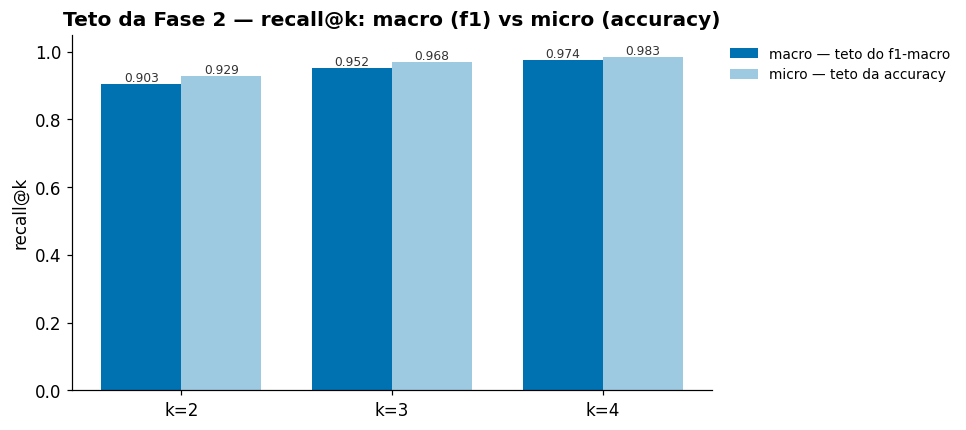

In [2]:
ceiling = load_recall_ceiling(RUN_DIR)
display(ceiling.round(4))

MACRO, MICRO = "recall_macro (f1)", "recall_micro (acc)"
ks = ceiling["k"].astype(int); x = np.arange(len(ks)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.2))
b1 = ax.bar(x - w/2, ceiling[MACRO], w, color=BLUE, label="macro — teto do f1-macro")
b2 = ax.bar(x + w/2, ceiling[MICRO], w, color="#9ecae1", label="micro — teto da accuracy")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f"{bar.get_height():.3f}",
                ha="center", fontsize=8, color=INK)
ax.set_xticks(x); ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylim(0, 1.05); ax.set_ylabel("recall@k")
ax.set_title("Teto da Fase 2 — recall@k: macro (f1) vs micro (accuracy)")
# legenda FORA da área do plot (à direita) — barras são altas e cobririam a legenda dentro
ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.savefig(FIG_DIR / "recall_at_k.png", bbox_inches="tight"); plt.show()

## 3. Filtered vs Baseline (por-fold + agregado)

Comparação **pareada** por `text_id` (só linhas onde GT, filtered e baseline são válidos). O consenso entra como um modelo a mais. **Métrica primária: f1-macro** (datasets desbalanceados); accuracy como apoio.

In [3]:
per_fold, models = compare_per_fold(DATASET, RUN_DIR, BASELINE_DIR)
cons_pf = compare_consensus_per_fold(DATASET, RUN_DIR, BASELINE_DIR)
if cons_pf is not None:
    per_fold = pd.concat([per_fold, cons_pf], ignore_index=True)
    models = models + ["consensus"]

agg = aggregate_by_mean(per_fold)
# f1-macro primeiro (datasets desbalanceados); accuracy como apoio
cols = ["model", "folds", "filtered_f1_mean", "baseline_f1_mean", "delta_f1_mean",
        "delta_f1_std", "filtered_acc_mean", "baseline_acc_mean", "delta_acc_mean",
        "filtered_invalid_rate_mean"]
display(agg[cols].round(4).sort_values("delta_f1_mean", ascending=False))

,model,folds,filtered_f1_mean,baseline_f1_mean,delta_f1_mean,delta_f1_std,filtered_acc_mean,baseline_acc_mean,delta_acc_mean,filtered_invalid_rate_mean
2,llama3.1-8b,10,0.6604,0.6025,0.0579,0.0041,0.6731,0.6111,0.0620,0.0249
1,deepseek-r1-8b,10,0.6106,0.5804,0.0303,0.0047,0.6272,0.6102,0.0170,0.0045
0,consensus,10,0.6363,0.6065,0.0298,0.0041,0.6568,0.6325,0.0244,0.0012
3,qwen3-8b,10,0.6147,0.5994,0.0153,0.0050,0.6435,0.6321,0.0114,0.0000


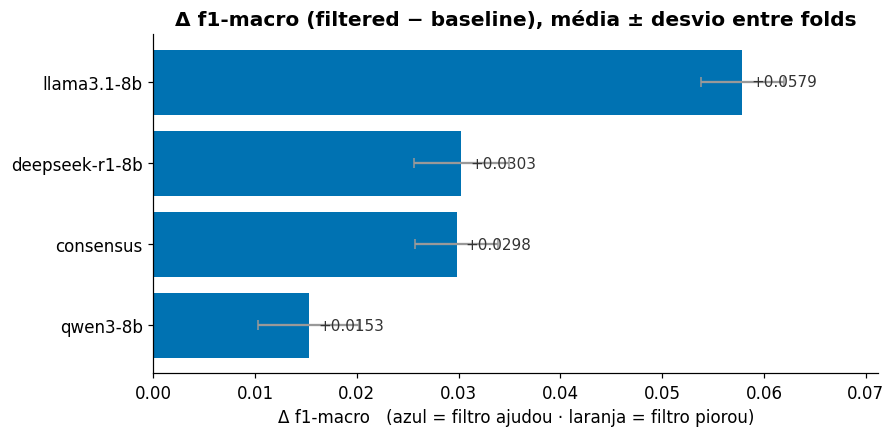

In [4]:
# Gráfico DIVERGENTE dos deltas de f1-macro (filtered - baseline) — métrica primária
a = agg.sort_values("delta_f1_mean")
colors = [BLUE if v >= 0 else ORANGE for v in a["delta_f1_mean"]]
fig, ax = plt.subplots(figsize=(8.5, 4))
bars = ax.barh(a["model"], a["delta_f1_mean"], color=colors,
               xerr=a["delta_f1_std"], error_kw=dict(ecolor="#999", capsize=3))
ax.axvline(0, color=INK, lw=1)
for v, y in zip(a["delta_f1_mean"], range(len(a))):
    ax.text(v + (0.0009 if v >= 0 else -0.0009), y, f"{v:+.4f}",
            va="center", ha="left" if v >= 0 else "right", color=INK, fontsize=10)
ax.set_title("Δ f1-macro (filtered − baseline), média ± desvio entre folds")
ax.set_xlabel("Δ f1-macro   (azul = filtro ajudou · laranja = filtro piorou)")
ax.margins(x=0.15)
fig.savefig(FIG_DIR / "delta_f1_macro.png", bbox_inches="tight"); plt.show()

## 4. Matrizes de confusão (heatmaps) — filtered

Linha = classe verdadeira, coluna = predita, valor = fração da linha (diagonal = acerto). É aqui que se enxerga **onde** o erro se concentra.

In [5]:
filtered = load_filtered(RUN_DIR).drop_duplicates("text_id")
gt = coerce_int(filtered["ground_truth"])
labels = sorted(x for x in set(gt.tolist()) if x != INVALID)
n = len(labels)
tick = [f"{i}:{str(NAMES.get(str(i), i))[:10]}" for i in labels]
cons = load_consensus_filtered(RUN_DIR).drop_duplicates("text_id")

def cm_frac(yt, yp):
    m = (yt != INVALID) & (yp != INVALID)
    cm = confusion_matrix(yt[m], yp[m], labels=labels).astype(float)
    rs = cm.sum(1, keepdims=True)
    return np.divide(cm, rs, out=np.zeros_like(cm), where=rs != 0)

def plot_cm(ax, yt, yp, title):
    """Heatmap de confusão (fração da linha) com número em TODA célula."""
    frac = cm_frac(yt, yp)
    im = ax.imshow(frac, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(tick, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(tick)
    for i in range(n):
        for j in range(n):
            v = frac[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=10,
                    color="white" if v > 0.5 else "#222222")
    ax.set_title(title); ax.set_xlabel("predita"); ax.set_ylabel("verdadeira")
    return im

MODELS = [
    ("deepseek-r1-8b", gt, coerce_int(filtered["deepseek-r1-8b_consensus"])),
    ("qwen3-8b",       gt, coerce_int(filtered["qwen3-8b_consensus"])),
    ("llama3.1-8b",    gt, coerce_int(filtered["llama3.1-8b_consensus"])),
]
CONS_YT = coerce_int(cons["ground_truth"])
CONS_YP = coerce_int(cons["resolved_annotation"])

### 4a. Consenso sozinho

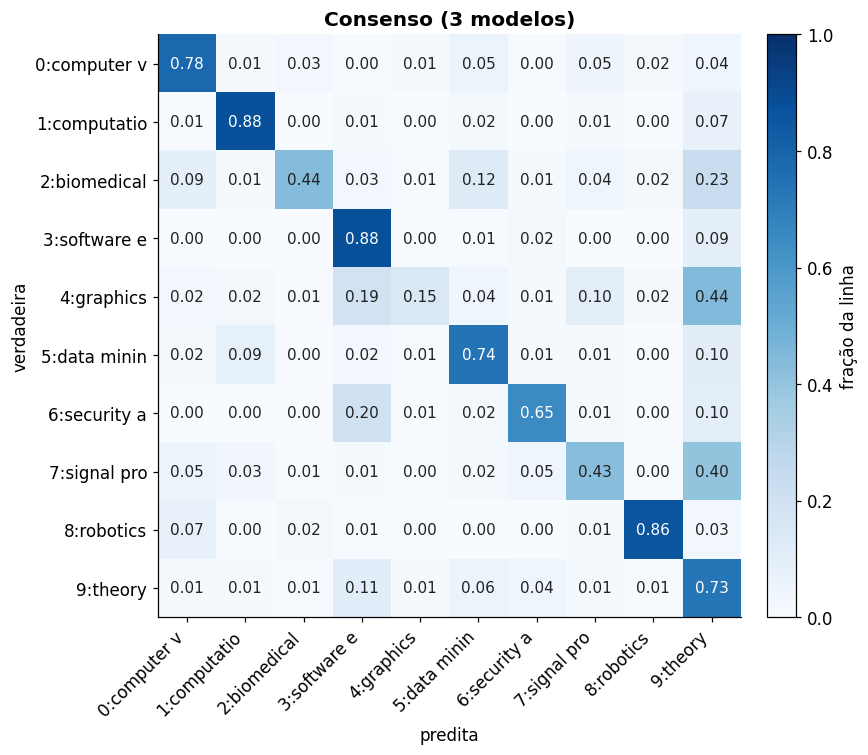

Salvo: data\results\dblp\two_phase\2026-08-03_04-02-09\figures\confusion_consensus.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
im = plot_cm(ax, CONS_YT, CONS_YP, "Consenso (3 modelos)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fração da linha")
plt.tight_layout()
fig.savefig(FIG_DIR / "confusion_consensus.png", bbox_inches="tight"); plt.show()
print("Salvo:", FIG_DIR / "confusion_consensus.png")

### 4b. Os 3 modelos lado a lado

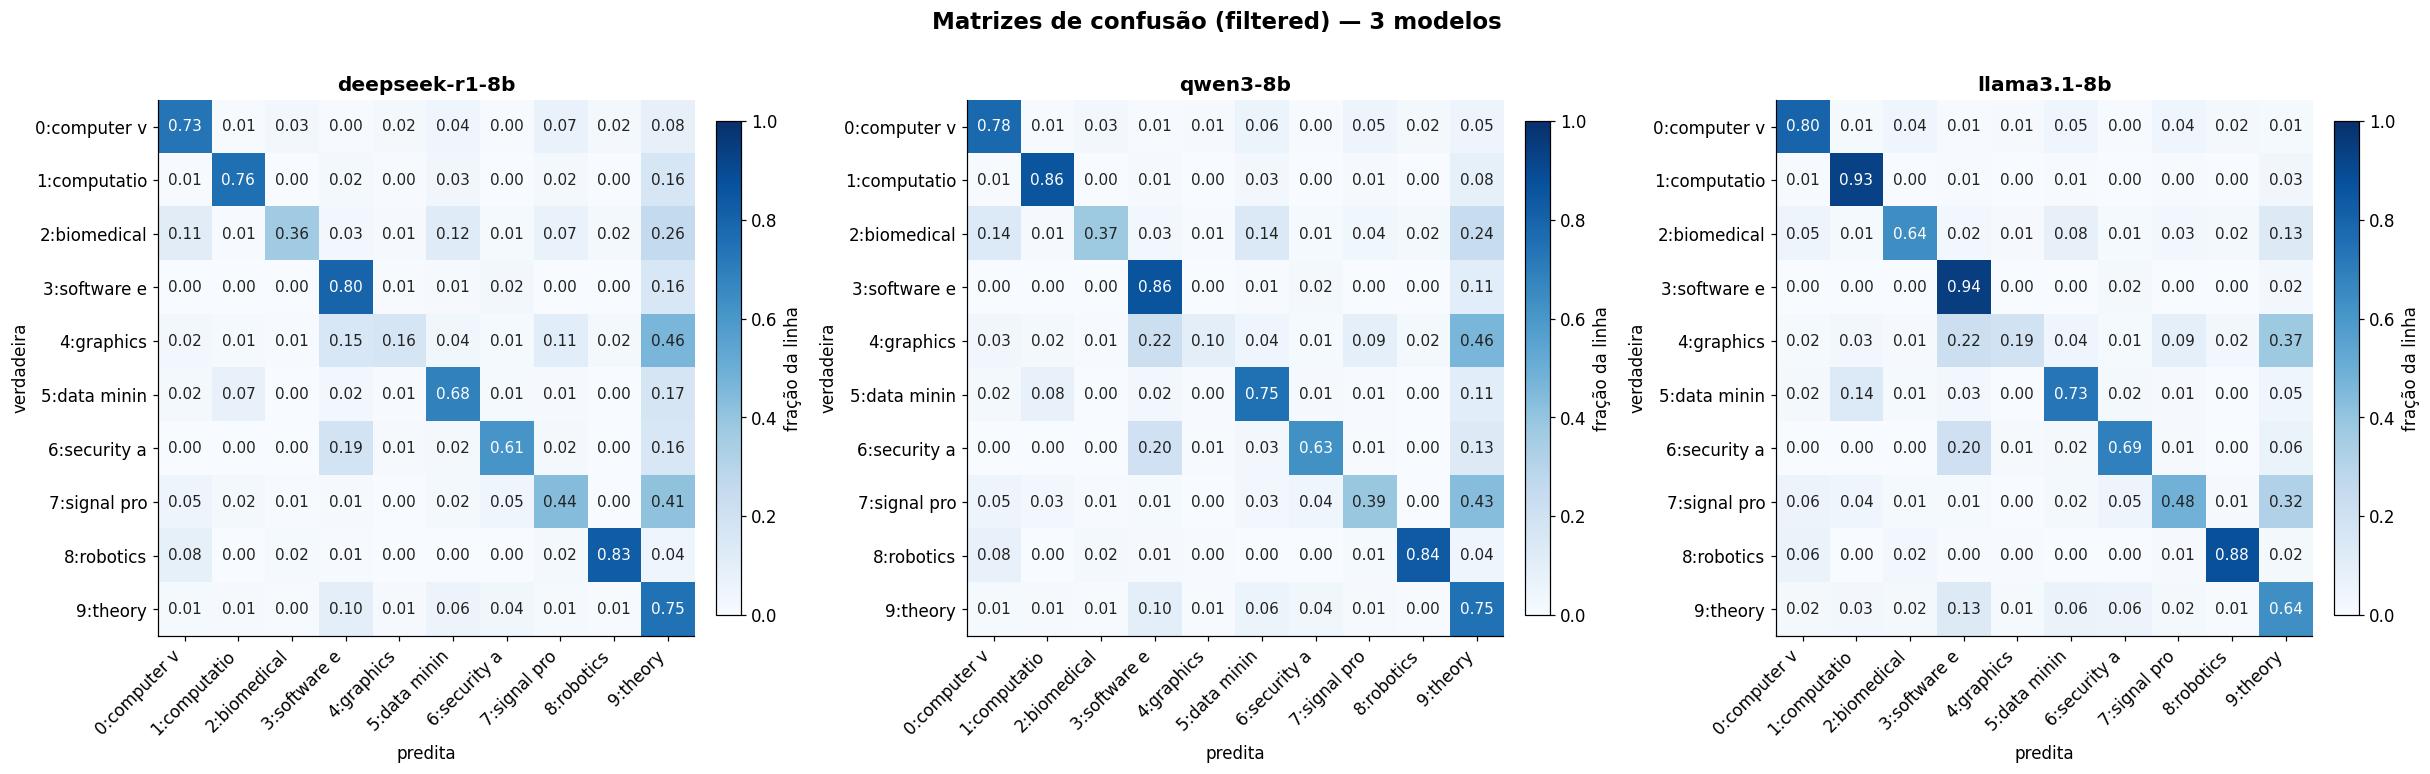

Salvo: data\results\dblp\two_phase\2026-08-03_04-02-09\figures\confusion_models.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)
for ax, (title, yt, yp) in zip(axes, MODELS):
    im = plot_cm(ax, yt, yp, title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="fração da linha")
fig.suptitle("Matrizes de confusão (filtered) — 3 modelos", fontsize=15, fontweight="bold")
fig.savefig(FIG_DIR / "confusion_models.png", bbox_inches="tight"); plt.show()
print("Salvo:", FIG_DIR / "confusion_models.png")

**Como ler:** classes bem separadas (crime, poetry) têm diagonal alta; o erro mora num cluster de
gêneros que se sobrepõem (history↔romance, young adult↔paranormal). O filtro mantém esse cluster junto
(são justamente as classes mais prováveis do LR) — por isso reduzir o espaço não elimina esses erros.

## 5. Ruído de rótulo — limite inferior

Sinal: os **3 modelos independentes unânimes numa classe ≠ GT** (no baseline, espaço completo — os modelos viram todas as classes, inclusive a do GT). É um **limite inferior** (casos onde os modelos discordam entre si não contam).

In [8]:
base = pd.read_csv(BASELINE_DIR / "annotations.csv").drop_duplicates("text_id")
bmodels = consensus_models(base)
bcols = [f"{m}_consensus" for m in bmodels]
for c in bcols + ["ground_truth"]:
    base[c] = coerce_int(base[c])

preds = base[bcols].to_numpy()
unan = np.array([(len(set(r)) == 1 and -1 not in set(r)) for r in preds])
unan_cls = np.where(unan, preds[:, 0], -1)
gtb = base["ground_truth"].to_numpy()
disagree = unan & (unan_cls != gtb) & (gtb != -1)

rows = []
for c in labels:
    m = gtb == c; n = int(m.sum()); dis = int((disagree & m).sum())
    from collections import Counter
    top = Counter(unan_cls[disagree & m]).most_common(1)
    rows.append({"classe": f"{c}:{NAMES.get(str(c), c)}", "n": n, "ruido_min": dis,
                 "taxa": dis / n if n else 0.0,
                 "alvo_principal": (NAMES.get(str(top[0][0]), top[0][0]) if top else "-")})
noise = pd.DataFrame(rows).sort_values("taxa", ascending=False)
overall = disagree.sum() / max(1, (gtb != -1).sum())
display(noise.assign(taxa=lambda d: (d.taxa * 100).round(1)))
print(f"Ruído GLOBAL (limite inferior): {disagree.sum()}/{(gtb!=-1).sum()} = {overall:.2%}")

,classe,n,ruido_min,taxa,alvo_principal
4,4:graphics,4934,1857,37.6,software engineering
6,6:security and cryptography,1414,346,24.5,software engineering
9,9:theory,9706,2199,22.7,software engineering
7,7:signal processing,3160,679,21.5,theory
5,5:data mining,4001,758,18.9,computational linguistics
2,2:biomedical engineering,1488,255,17.1,theory
0,0:computer vision,4278,430,10.1,signal processing
8,8:robotics,1415,95,6.7,computer vision
1,1:computational linguistics,4482,80,1.8,computer vision
3,3:software engineering,3175,48,1.5,security and cryptography


Ruído GLOBAL (limite inferior): 6747/38053 = 17.73%


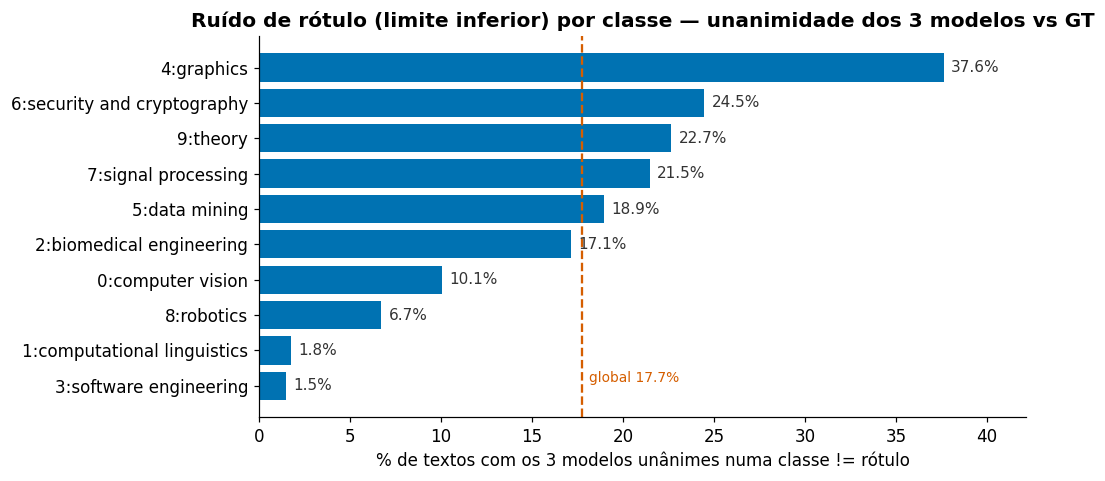

In [9]:
# Gráfico do ruído por classe (sequencial single-hue; rótulos diretos em %)
n2 = noise.sort_values("taxa")
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(n2["classe"], n2["taxa"] * 100, color=BLUE)
for v, y in zip(n2["taxa"] * 100, range(len(n2))):
    ax.text(v + 0.4, y, f"{v:.1f}%", va="center", color=INK, fontsize=10)
ax.axvline(overall * 100, color=ORANGE, lw=1.5, ls="--")
ax.text(overall * 100 + 0.4, 0.1, f"global {overall*100:.1f}%", color=ORANGE, fontsize=9)
ax.set_title("Ruído de rótulo (limite inferior) por classe — unanimidade dos 3 modelos vs GT")
ax.set_xlabel("% de textos com os 3 modelos unânimes numa classe != rótulo")
ax.margins(x=0.12)
fig.savefig(FIG_DIR / "label_noise.png", bbox_inches="tight"); plt.show()

In [10]:
# Evidência qualitativa: a CLASSE MAIS RUIDOSA e seu alvo unânime principal (auto)
from collections import Counter
worst = int(noise.iloc[0]["classe"].split(":")[0])            # noise já está ordenado desc por taxa
tgt = int(Counter(unan_cls[disagree & (gtb == worst)]).most_common(1)[0][0])
sub = base[(gtb == worst) & unan & (unan_cls == tgt)]
print(f"Classe mais ruidosa: GT='{NAMES.get(str(worst), worst)}' -> unânime em '{NAMES.get(str(tgt), tgt)}' "
      f"({len(sub)} casos). Amostra:\n")
for i, t in enumerate(sub["text"].head(10), 1):
    print(f"[{i}] {str(t)[:200]}".replace(chr(10), " "))

Classe mais ruidosa: GT='graphics' -> unânime em 'software engineering' (1129 casos). Amostra:

[1] optimizing agile user-centred design. the goal of this workshop is to improve future agile user centred design (ucd) experiences for user experience (ux) practitioners (such as interaction designers, 
[2] metisse is not a 3d desktop! twenty years after the general adoption of overlapping windows and the desktop metaphor, modern window systems differ mainly in minor details such as window decorations or
[3] when one-arm bandits go digital: designing a casino back-end system. frog design collaborated with a gaming machine manufacturer to design a back-end system to address the needs of casino floor manage
[4] experience buffers: a socially appropriate, selective archiving tool for evidence-based care. diagnosis, treatment, and monitoring of interventions for children with autism can profit most when caregi
[5] constraint satisfaction for relative location assignment and scheduling. tight d

## 6. Conclusões

- **Métrica primária: f1-macro** (datasets desbalanceados). Os números por modelo estão na seção 3 e
  no gráfico de deltas acima — leia o Δ f1-macro, não o de accuracy.
- **O erro residual é ambiguidade entre classes vizinhas**, não excesso de classes: o filtro remove os
  distratores fáceis mas mantém junto o cluster confundível (veja as matrizes da seção 4).
- **O ground-truth é ruidoso** (seção 5): parte do "erro" é rótulo contestado, então a métrica medida
  **subestima** a qualidade real das anotações.

Figuras salvas em `figures/` dentro do run. Para re-executar em outro dataset, rode o builder com
`python build_notebook.py <dataset>` (ou troque `DATASET` na seção 1).
